# Data cleaning and exploration

Checks the five FRED series this pipeline pulls (`data/raw/*.parquet`) for
missing values, reporting gaps, and range sanity before they reach
`model.py`, and shows exactly what the quarterly resampling and merge in
`model.py` does to the sample.

Not part of the containerized pipeline. Run by hand, locally, after
`fetch.py` has populated `data/raw/`.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

from model import (
    REGRESSION_SERIES, START, load_quarterly,
    build_quarterly_frame, build_change_frame, CHANGES_PREDICTORS,
)

DATA_DIR = REPO_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

SERIES_NAMES = ["HPI", "Mortgage_30yr", "Unemployment_Rate", "CPI", "Permits"]

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white"})


## Loading the raw series

All five series `fetch.py` pulls, at native reporting frequency (not yet
resampled to quarterly). Permits is included here even though `model.py`
excludes it from the regression, since this notebook is about the data,
not the model.


In [2]:
raw = {name: pd.read_parquet(RAW_DIR / f"{name}.parquet")[name] for name in SERIES_NAMES}

summary = pd.DataFrame({
    name: {
        "rows": len(s),
        "start": s.index.min().date(),
        "end": s.index.max().date(),
        "nulls": s.isna().sum(),
    }
    for name, s in raw.items()
}).T
summary


,rows,start,end,nulls
HPI,206,1975-01-01,2026-04-01,0
Mortgage_30yr,2894,1971-04-02,2026-09-10,0
Unemployment_Rate,606,1976-01-01,2026-07-01,0
CPI,574,1966-12-01,2026-08-01,0
Permits,463,1988-01-01,2026-07-01,0


## Missing values within each series

`fetch.py` already drops nulls on fetch (`.dropna()` in `fetch()`), so this
should be, and is, all zeros. Confirmed here rather than assumed.


In [3]:
null_counts = {name: int(s.isna().sum()) for name, s in raw.items()}
null_counts


{'HPI': 0, 'Mortgage_30yr': 0, 'Unemployment_Rate': 0, 'CPI': 0, 'Permits': 0}

## Reporting gaps

Zero nulls in the data that exists doesn't mean the data is complete, a
whole reporting period can be missing from the index rather than present as
a null. This checks the gap between consecutive observations against each
series' expected native frequency and flags anything wider than expected.


In [4]:
EXPECTED_GAP_DAYS = {
    "HPI": 95,              # quarterly
    "Mortgage_30yr": 10,    # weekly
    "Unemployment_Rate": 35,  # monthly
    "CPI": 35,              # monthly
    "Permits": 35,          # monthly
}

gap_findings = {}
for name, s in raw.items():
    diffs = s.index.to_series().diff().dropna()
    big = diffs[diffs.dt.days > EXPECTED_GAP_DAYS[name]]
    gap_findings[name] = big

for name, big in gap_findings.items():
    print(f"--- {name}: {len(big)} gap(s) wider than expected ---")
    # CPI's early history is bimonthly across ~20 years, dozens of
    # same-sized gaps, show the shape (first/last) rather than every one.
    to_show = big if len(big) <= 6 else pd.concat([big.head(3), big.tail(3)])
    for date, gap in to_show.items():
        print(f"  {(date - gap).date()} -> {date.date()}  ({gap.days} days)")
    if len(big) > 6:
        print(f"  ... {len(big) - 6} more, all ~60-90 days, all before 1987 except the last")


--- HPI: 0 gap(s) wider than expected ---
--- Mortgage_30yr: 0 gap(s) wider than expected ---
--- Unemployment_Rate: 1 gap(s) wider than expected ---
  2025-09-01 -> 2025-11-01  (61 days)
--- CPI: 99 gap(s) wider than expected ---
  1966-12-01 -> 1967-03-01  (90 days)
  1967-03-01 -> 1967-06-01  (92 days)
  1967-06-01 -> 1967-09-01  (92 days)
  1986-08-01 -> 1986-10-01  (61 days)
  1986-10-01 -> 1986-12-01  (61 days)
  2025-09-01 -> 2025-11-01  (61 days)
  ... 93 more, all ~60-90 days, all before 1987 except the last
--- Permits: 0 gap(s) wider than expected ---


### What the gaps are

**CPI (`CUUR0400SA0`) was reported bimonthly, not monthly, from the start of
the series in 1966 through late 1986.** Every early-period gap above is ~60
or ~90 days rather than ~30, consistent with that. This predates
`START = 1990-01-01`, so it never reaches the regression sample, it only
means the earliest decades of CPI history (outside the sample) are built
from about half as many monthly readings as later years.

**Both CPI and Unemployment_Rate are missing an October 2025 observation.**
This isn't a pipeline bug, it's a real gap in the underlying source data.
The federal government shutdown from October 1 to November 12, 2025 stopped
BLS data collection entirely for that window. The October CPI print was
cancelled outright, and BLS has stated the October 2025 unemployment rate
(from the Current Population Survey household survey) will never be
collected retroactively and is permanently missing, not delayed.

Sources, [BLS on the 2025 shutdown's impact on CPI](https://www.bls.gov/cpi/additional-resources/2025-federal-government-shutdown-impact-cpi.htm)
and [US News on the cancelled October CPI report](https://www.usnews.com/news/politics/articles/2025-11-21/us-cancels-release-of-cpi-report-for-october-because-of-government-shutdown).

Neither gap breaks the pipeline. `model.py` resamples to quarterly means, so
a missing month means that quarter's mean is computed from fewer underlying
readings, not that the quarter itself goes missing, checked directly below.


## Quarterly resampling and the model's sample

What `model.py`'s `build_quarterly_frame()` actually does, resample each of
the four regression series to quarterly means, merge them, then drop any
quarter where one of the four is still missing.


In [5]:
quarterly_each = {name: load_quarterly(name) for name in REGRESSION_SERIES}
merged = pd.DataFrame(quarterly_each).loc[START:]

print(f"quarters before dropna: {len(merged)}")
print(f"quarters after dropna:  {len(merged.dropna())}")
print()
print("dropped quarter(s):")
merged[merged.isna().any(axis=1)]


quarters before dropna: 147
quarters after dropna:  146

dropped quarter(s):


,HPI,Mortgage_30yr,Unemployment_Rate,CPI
observation_date,,,,
2026-09-30,NaN,6.622727,5.1,354.4115


The one dropped quarter is the current trailing quarter, HPI (FHFA
all-transactions) hasn't been published for it yet since it isn't over.
That's the mechanism behind the README's claim that `model.py` rolls its
sample end date forward to "the latest complete quarter", it's this
`dropna()`, not a separate date calculation, and it's expected, not a data
quality problem.


## Value ranges and distributions

Same four series, now at native frequency, summary statistics and
distribution shape, as a sanity check against `fetch.py`'s validation
ranges (which only check min/max, not shape).


In [6]:
pd.DataFrame({name: raw[name].describe() for name in REGRESSION_SERIES}).T


,count,mean,std,min,25%,50%,75%,max
HPI,206.0,371.371068,259.704480,41.65,158.6100,281.095,551.0175,975.220
Mortgage_30yr,2894.0,7.681123,3.179602,2.65,5.5225,7.215,9.2175,18.630
Unemployment_Rate,606.0,7.080198,2.161451,3.80,5.3250,6.700,8.3750,16.100
CPI,574.0,186.946552,78.905984,32.90,133.7000,185.400,240.1170,355.254


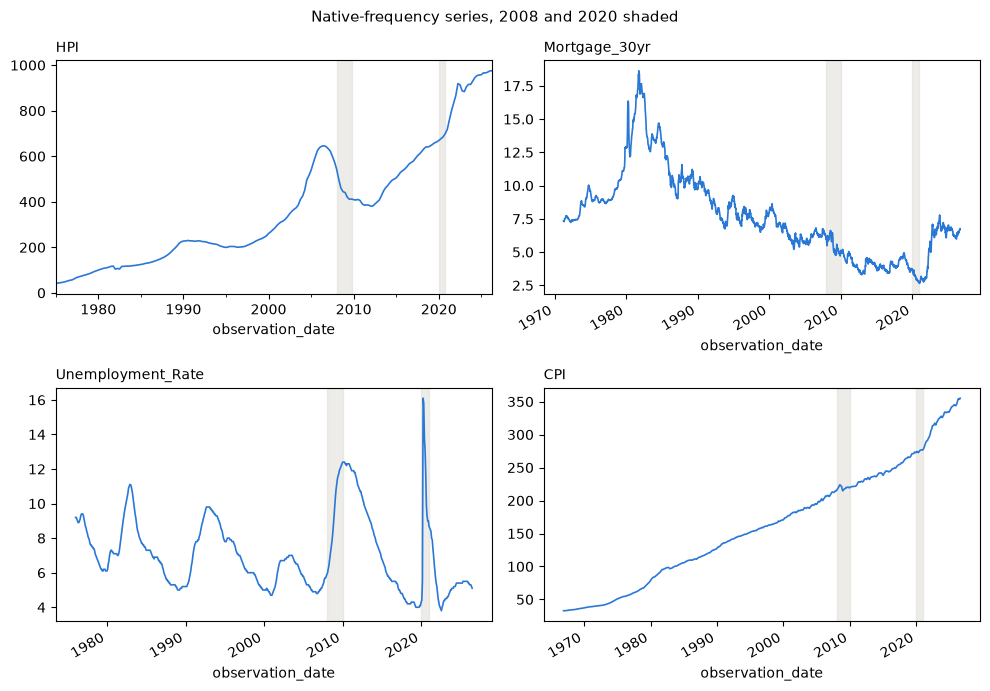

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for ax, name in zip(axes.flat, REGRESSION_SERIES):
    raw[name].plot(ax=ax, color="#2a78d6", linewidth=1.2)
    ax.set_title(name, fontsize=10, loc="left")
    ax.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31"), color="#e1e0d9", alpha=0.6, zorder=0)
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"), color="#e1e0d9", alpha=0.6, zorder=0)
fig.suptitle("Native-frequency series, 2008 and 2020 shaded", fontsize=11)
fig.tight_layout()
plt.show()


## Change variables and correlation

The same four series after `model.py`'s `pct_change()` transform, which is
what actually feeds the regression. Correlation matrix here is a visual,
approachable version of the VIF check `model.py` already runs numerically.


In [8]:
quarterly = build_quarterly_frame()
chg = build_change_frame(quarterly)
chg[CHANGES_PREDICTORS + ["HPI_chg"]].describe()


,HPI_chg_lag1,Mortgage_30yr_chg,Unemployment_Rate_chg,CPI_chg,HPI_chg
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,1.048294,-0.116397,0.903186,0.698775,1.045764
std,2.534525,6.792074,19.514242,0.619640,2.535421
min,-8.264874,-13.377354,-23.851204,-2.390771,-8.264874
25%,-0.305401,-4.609219,-3.836479,0.332241,-0.305401
50%,1.098888,-1.429513,-1.306734,0.678397,1.098888
75%,2.251285,2.972085,1.737013,1.057265,2.251285
max,10.159906,37.774200,221.830986,2.800281,10.159906


`Unemployment_Rate_chg`'s max, 222%, is not a data error. California's
unemployment rate went from 4.7% to 15.2% in a single quarter, Q2 2020,
the same COVID shock already visible in the shaded 2020 region above.
`pct_change()` on a rate that small makes an already-large move look even
more extreme in percentage terms, worth knowing before reading too much
into that one number on its own.


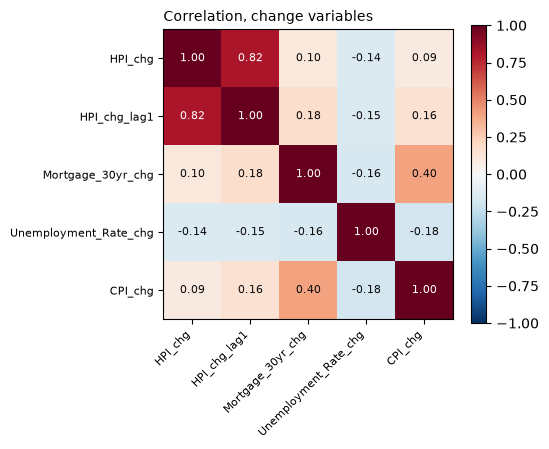

In [9]:
corr = chg[["HPI_chg"] + CHANGES_PREDICTORS].corr()

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                 color="white" if abs(corr.iloc[i, j]) > 0.6 else "#0b0b0b")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation, change variables", fontsize=10, loc="left")
fig.tight_layout()
plt.show()


## Summary of findings

- No null values in any raw series as fetched, `fetch.py`'s own
  `.dropna()` already guarantees this, confirmed directly rather than
  assumed.
- CPI was reported bimonthly before late 1986. Outside the modeling sample
  (`START = 1990-01-01`), so it affects data density in a period this
  project never uses, not the regression itself.
- CPI and Unemployment_Rate are both missing October 2025, a real,
  documented BLS data gap from the 2025 government shutdown, not a fetch
  bug. It thins one quarter's average, it doesn't create a missing quarter.
- Exactly one quarter gets dropped from the regression frame, the current,
  still-incomplete trailing quarter. That's the intended "rolling sample
  end date" behavior described in the README, not a silent data loss.
- Correlations among the four change variables are all modest, consistent
  with the low VIFs `model.py` already reports, nothing here is proxying
  for something else.
